# Lab: Deep Learning MLP with PyTorch

* Author: geoffroy.peeters@telecom-paris.fr
* Date: 2026-02-18

The goal of the Lab is to use (train and test) an MLP for a multi-class classification task on real data.

You will
- download the data from the internet.
- process the data using Pandas:
    - load the .xls file, split into X and y, split into train and eval-set.
- create a pytorch Dataset to allow getting them on the fly.
- write an MLP model using the `nn.Module` class formalism.
- write a loop over epochs in wich you train the model over mini-batch of the training-set and evaluate over the eval-set.
    - display at each epoch the losses and accuracies over training and test data.
- plot the losses and accuracies evoluation over epochs.

You will use the 'Dry Bean Dataset' descibed here https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset and downloadable here https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip.

## Your tasks
- 1) Fill-in the missing part
- 2) Correct the error mades in the text and in the provided code


# Import packages

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import urllib.request

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Data acquisition

Get the Dry Bean Dataset

Documentation: https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset

URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip

In [33]:
!rm DryBeanDataset.zip
!rm -rf ./DryBeanDataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip"
urllib.request.urlretrieve(url, "DryBeanDataset.zip")

!unzip DryBeanDataset.zip

Archive:  DryBeanDataset.zip
   creating: DryBeanDataset/
  inflating: DryBeanDataset/Dry_Bean_Dataset.arff  
  inflating: DryBeanDataset/Dry_Bean_Dataset.txt  
  inflating: DryBeanDataset/Dry_Bean_Dataset.xlsx  


# Data preprocessing (using pandas and sklearn)

Process the data
* load the .xls file data using `pandas` (read_excel)
* split into X (all columns except `Class`) and y (column `Class`) using `pandas`
* convert y to integer using `sklearn` (LabelEncoder)
* split into train and valid datasets using `sklearn` (train_test_split), we use a 80\% train, 20\% validation split
* standardize the X of train and valid using `sklearn` (StandardScaler)



In [34]:
def load_and_preprocess(data_file):
    df=pd.read_excel(data_file)
    le=LabelEncoder()
    y=le.fit_transform(df['Class'])
    X=df.drop(columns=['Class']).to_numpy()
    X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=0.2 )
    Scaler=StandardScaler()
    X_train=Scaler.fit_transform(X_train)
    X_valid=Scaler.transform(X_valid)
    return X_train, X_valid, y_train, y_valid, len(np.unique(y))

data_file = 'DryBeanDataset/Dry_Bean_Dataset.xlsx'
X_train, X_valid, y_train, y_valid, num_classes = load_and_preprocess(data_file)

In [35]:
print(X_train.shape)
print(y_train.shape)
print(set(y_train))

print(X_valid.shape)
print(y_valid.shape)
print(set(y_valid))

(10888, 16)
(10888,)
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}
(2723, 16)
(2723,)
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}


# Write the pytorch Dataset and Dataloader

create a pytorch Dataset to allow getting X and y on the fly
* we need to convert the data from numpy to torch-tensors

In [36]:
class BeanDataset(Dataset):
    def __init__(self, X, y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = BeanDataset(X_train, y_train)
valid_dataset = BeanDataset(X_valid, y_valid)

# DataLoaders handle batching, shuffling, and multi-process loading.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

# Write the MLP model using `nn.Module`

The MLP model as the following architecture: `input_dim -> 128 -> 64 -> 64 -> output_dim`
* `output_dim`corresponds to the number of classes
* we put a `ReLU` between each layer
* we use a `softmax` activation at the end (since we deal with a multi-class problem)

In [37]:

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, output_dim)

    def forward(self, x):
        x=nn.ReLU()(self.fc1(x))
        x=nn.ReLU()(self.fc2(x))
        x=nn.ReLU()(self.fc3(x))

        return self.fc4(x)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(X_train.shape[1], num_classes).to(device)

# Define the loss to be minimized and the optimizer

We use a loss named `MSE` since we deal multi-class classification.

We optimize the model using an `Adam` optimizer using a learning rate of 0.001.

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Write the main loop

We write the main loop over epochs.
For each epoch
* we train the model
    * we set the model in train mode using `model.train()`
    * we loop over mini-batches of training data: zero_grad(), forward, loss, backward, step
    * we compute the current accuracy
* we evaluate the currently trained model on the validation data
    * we set the model in train mode using `model.eval()`
    * we loop over mini-batches of validation data: forward, loss
    * we compute the current loss and accuracy
* we store and print the loss and accuracy for training and validation data

In [39]:
epochs = 100
history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    for inputs,labels in iter(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 3. Backward pass (Autograd en action)
        loss.backward()

        # 4. Mise à jour des poids
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()

    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad(): # On désactive Autograd ici pour gagner de la vitesse
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()

    t_loss = train_loss / len(train_loader.dataset)
    t_acc = train_correct / len(train_loader.dataset)
    v_loss = val_loss / len(valid_loader.dataset)
    v_acc = val_correct / len(valid_loader.dataset)

    history['train_loss'].append(t_loss)
    history['valid_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['valid_acc'].append(v_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

Epoch 1/100 | Train Loss: 0.6467 Acc: 0.7911 | Val Loss: 0.2517 Acc: 0.9115
Epoch 2/100 | Train Loss: 0.2199 Acc: 0.9206 | Val Loss: 0.2235 Acc: 0.9199
Epoch 3/100 | Train Loss: 0.2066 Acc: 0.9254 | Val Loss: 0.2385 Acc: 0.9188
Epoch 4/100 | Train Loss: 0.1983 Acc: 0.9251 | Val Loss: 0.2233 Acc: 0.9214
Epoch 5/100 | Train Loss: 0.1987 Acc: 0.9271 | Val Loss: 0.2109 Acc: 0.9203
Epoch 6/100 | Train Loss: 0.1932 Acc: 0.9307 | Val Loss: 0.2158 Acc: 0.9199
Epoch 7/100 | Train Loss: 0.1896 Acc: 0.9300 | Val Loss: 0.2028 Acc: 0.9273
Epoch 8/100 | Train Loss: 0.1875 Acc: 0.9320 | Val Loss: 0.2071 Acc: 0.9225
Epoch 9/100 | Train Loss: 0.1858 Acc: 0.9309 | Val Loss: 0.2006 Acc: 0.9291
Epoch 10/100 | Train Loss: 0.1838 Acc: 0.9315 | Val Loss: 0.2039 Acc: 0.9254
Epoch 11/100 | Train Loss: 0.1844 Acc: 0.9317 | Val Loss: 0.2034 Acc: 0.9269
Epoch 12/100 | Train Loss: 0.1805 Acc: 0.9341 | Val Loss: 0.2050 Acc: 0.9266
Epoch 13/100 | Train Loss: 0.1792 Acc: 0.9342 | Val Loss: 0.2056 Acc: 0.9280
Epoch 14

# Plot the loss and accuracy evolution over epoches for train and test data

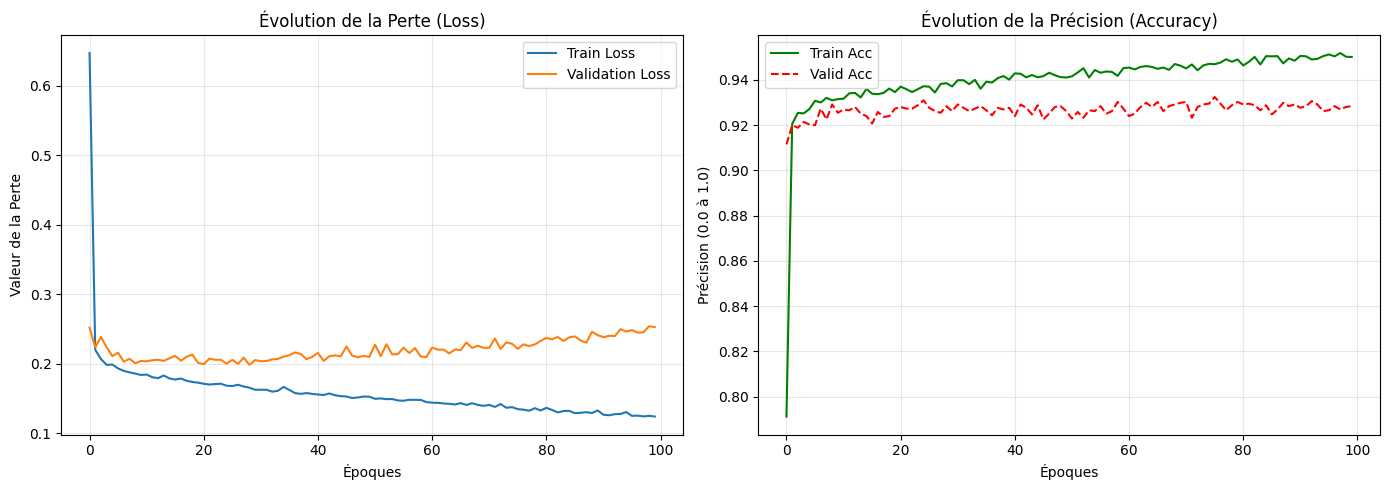

In [40]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['valid_loss'], label='Validation Loss')
plt.title('Évolution de la Perte (Loss)')
plt.xlabel('Époques')
plt.ylabel('Valeur de la Perte')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='green')
plt.plot(history['valid_acc'], label='Valid Acc', color='red', linestyle='--')
plt.title('Évolution de la Précision (Accuracy)')
plt.xlabel('Époques')
plt.ylabel('Précision (0.0 à 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajustement automatique de l'espace entre les graphiques
plt.tight_layout()

plt.show()

# Early-stopping

In the above, we start doing over-fitting (the loss still decreases for the training data but starts increasing for the validation data). We should stop before this. This is named **early-stopping**. Write a test in the training loop which stop the training when the validation-loss starts increasing.

In [41]:
# Réinitialisation du modèle pour repartir de zéro
model_es = MLP(X_train.shape[1], num_classes).to(device)
optimizer_es = optim.Adam(model_es.parameters(), lr=0.001)

patience = 5  # Nombre d'époques à attendre sans amélioration
best_val_loss = float('inf')
counter = 0
history_early_stopping = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}

for epoch in range(epochs):

    model_es.train()
    train_loss = 0.0
    train_correct = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_es.zero_grad()
        outputs = model_es(inputs)
        loss = criterion(outputs, labels) # On peut réutiliser le criterion défini plus haut
        loss.backward()
        optimizer_es.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()

    model_es.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_es(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()

    t_loss = train_loss / len(train_loader.dataset)
    t_acc = train_correct / len(train_loader.dataset)
    v_loss = val_loss / len(valid_loader.dataset)
    v_acc = val_correct / len(valid_loader.dataset)

    history_early_stopping['train_loss'].append(t_loss)
    history_early_stopping['valid_loss'].append(v_loss)
    history_early_stopping['train_acc'].append(t_acc)
    history_early_stopping['valid_acc'].append(v_acc)

    print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        counter = 0
        torch.save(model_es.state_dict(), 'best_model.pth')
    else:
        counter += 1
        print(f"-> EarlyStopping counter: {counter} out of {patience}")

        if counter >= patience:
            print(f"!!! Early Stopping déclenché à l'époque {epoch+1} !!!")
            print(f"Le meilleur modèle a été sauvegardé avec une Loss de validation de {best_val_loss:.4f}")
            break

Epoch 001/100 | Train Loss: 0.6433 Acc: 0.8072 | Val Loss: 0.2513 Acc: 0.9082
Epoch 002/100 | Train Loss: 0.2274 Acc: 0.9169 | Val Loss: 0.2259 Acc: 0.9185
Epoch 003/100 | Train Loss: 0.2073 Acc: 0.9257 | Val Loss: 0.2256 Acc: 0.9188
Epoch 004/100 | Train Loss: 0.2027 Acc: 0.9243 | Val Loss: 0.2084 Acc: 0.9251
Epoch 005/100 | Train Loss: 0.1978 Acc: 0.9263 | Val Loss: 0.2076 Acc: 0.9258
Epoch 006/100 | Train Loss: 0.1936 Acc: 0.9293 | Val Loss: 0.2022 Acc: 0.9251
Epoch 007/100 | Train Loss: 0.1903 Acc: 0.9292 | Val Loss: 0.2039 Acc: 0.9251
-> EarlyStopping counter: 1 out of 5
Epoch 008/100 | Train Loss: 0.1905 Acc: 0.9289 | Val Loss: 0.2236 Acc: 0.9229
-> EarlyStopping counter: 2 out of 5
Epoch 009/100 | Train Loss: 0.1891 Acc: 0.9280 | Val Loss: 0.2048 Acc: 0.9254
-> EarlyStopping counter: 3 out of 5
Epoch 010/100 | Train Loss: 0.1853 Acc: 0.9308 | Val Loss: 0.2037 Acc: 0.9225
-> EarlyStopping counter: 4 out of 5
Epoch 011/100 | Train Loss: 0.1859 Acc: 0.9304 | Val Loss: 0.2159 Acc: 0

# Correction (to be done during peer-grading)

During the peer-grading phase, you will note the lab over 10.

- 6 parts are to be filled-in (# --- 1/2/3/4/5/6). You will assign 1 point for each part (the code should be correct and you should be able to run it).
- 2 errors have been introduced in the text and/or provided-code. You will assign 1 point for each error found
- If the whole code run and provides the loss/epoch and accuracy/epoch curves given above (which involves writing the code and correcting the errors), you will give an extra 2 points.